In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [88]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from src.cnn.scratch_layers_cnn import MaxPooling2D, Flatten, LocallyConnected2D
from src.cnn.keras_layers import KerasLocallyConnected2D
from src.cnn.keras_models import build_baseline_cnn, build_local_cnn
from src.common.dense import Dense
from src.cnn.weight_loader_cnn import build_scratch_from_keras_model
from src.common.image_utils import load_image
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from pathlib import Path
import json
import nltk


from src.common.image_utils import load_image, load_images, list_image_paths_by_class
from src.rnn_lstm.caption_preprocess import clean_caption, build_vocabulary, preprocess_captions
from src.rnn_lstm.scratch_decoder import build_decoder_model
from src.rnn_lstm.inference_utils import ScratchDecoderInference, evaluate_model, evaluate_model_keras

Jumlah gambar: 8091
(150, 150, 3)
0.0 1.0


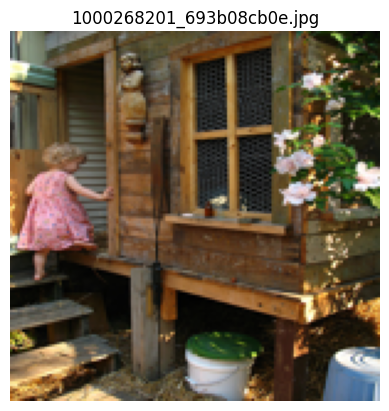

In [9]:
IMAGE_DIR = '../../data/raw/flickr8k'
image_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]
total_images = len(image_files)
print(f"Jumlah gambar: {total_images}")

img = load_image(Path(IMAGE_DIR) / image_files[0], target_size=(150, 150))

print(img.shape)
print(img.min(), img.max())

plt.imshow(img)
plt.title(image_files[0])
plt.axis("off")
plt.show()

# Bagian 1

In [12]:
OUTPUT_DIR = '../../results/rnn_lstm'
encoder_model = InceptionV3(weights='imagenet', include_top=False, pooling='avg')

encoder_model.trainable = False

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [13]:
IMAGE_LOAD_BATCH_SIZE = 64

for i in range(0, total_images, IMAGE_LOAD_BATCH_SIZE):
    batch_files = image_files[i : i + IMAGE_LOAD_BATCH_SIZE]
    batch_paths = [os.path.join(IMAGE_DIR, f) for f in batch_files]

    batch_images = load_images(batch_paths, target_size=(299, 299))

    # inceptionv3 input range: [-1, 1]
    features = encoder_model.predict(batch_images, verbose=0)

    for j, file_name in enumerate(batch_files):
        base_name = os.path.splitext(file_name)[0]
        save_path = os.path.join(OUTPUT_DIR, f"{base_name}.npy")

        np.save(save_path, features[j])

    print(f"Processed {min(i + IMAGE_LOAD_BATCH_SIZE, total_images)} / {total_images} images")

print("Ekstraksi fitur selesai")

Processed 64 / 8091 images
Processed 128 / 8091 images
Processed 192 / 8091 images
Processed 256 / 8091 images
Processed 320 / 8091 images
Processed 384 / 8091 images
Processed 448 / 8091 images
Processed 512 / 8091 images
Processed 576 / 8091 images
Processed 640 / 8091 images
Processed 704 / 8091 images
Processed 768 / 8091 images
Processed 832 / 8091 images
Processed 896 / 8091 images
Processed 960 / 8091 images
Processed 1024 / 8091 images
Processed 1088 / 8091 images
Processed 1152 / 8091 images
Processed 1216 / 8091 images
Processed 1280 / 8091 images
Processed 1344 / 8091 images
Processed 1408 / 8091 images
Processed 1472 / 8091 images
Processed 1536 / 8091 images
Processed 1600 / 8091 images
Processed 1664 / 8091 images
Processed 1728 / 8091 images
Processed 1792 / 8091 images
Processed 1856 / 8091 images
Processed 1920 / 8091 images
Processed 1984 / 8091 images
Processed 2048 / 8091 images
Processed 2112 / 8091 images
Processed 2176 / 8091 images
Processed 2240 / 8091 images
P

# Bagian 2

In [34]:
CAPTIONS_FILE = "../../data/captions.txt"
FEATURES_DIR = "../../results/rnn_lstm"
OUTPUT_DIR = "../../models/rnn_lstm"
VOCAB_PATH = "../../models/rnn_lstm/vocab.json"

os.makedirs(OUTPUT_DIR, exist_ok=True)

## sanitize caption

In [25]:
print("Membersihkan captions")
raw_captions_dict = {}

with open(CAPTIONS_FILE, 'r', encoding='utf-8') as f:
    lines = f.readlines()

    for line in lines[1:]:
        line = line.strip()
        if not line:
            continue

        parts = line.split(',', 1)
        if len(parts) == 2:
            img_filename, caption = parts

            img_id = os.path.splitext(img_filename)[0]

            if img_id not in raw_captions_dict:
                raw_captions_dict[img_id] = []

            cleaned = clean_caption(caption)
            raw_captions_dict[img_id].append(cleaned)

all_captions = [cap for caps in raw_captions_dict.values() for cap in caps]
print(f'Jumlah captions: {len(all_captions)}')
for i in range(3):
    print(i+1, all_captions[i])
print("...")


Membersihkan captions
Jumlah captions: 40455
1 <start> a child in a pink dress is climbing up a set of stairs in an entry way <end>
2 <start> a girl going into a wooden building <end>
3 <start> a little girl climbing into a wooden playhouse <end>
...


## build vocab

In [ ]:
vocab = build_vocabulary(all_captions, vocab_threshold=5)
vocab_size = len(vocab)

with open(VOCAB_PATH, 'w') as f:
    json.dump(vocab, f)
print(f"Jumlah tipe token: {vocab_size}")



Jumlah tipe token: 2988


In [28]:
# count maksimum sequence length untuk padding
max_seq_len = max(len(cap.split()) for cap in all_captions)
print(f"Panjang maksimum caption (max_seq_len): {max_seq_len}")

image_ids, X_caption, y_caption = preprocess_captions(raw_captions_dict, vocab, max_seq_len)

Panjang maksimum caption (max_seq_len): 37


In [50]:

X_cnn = []
missing_count = 0

for img_id in image_ids:
    feature_path = os.path.join(FEATURES_DIR, f"{img_id}.npy")
    if os.path.exists(feature_path):
        feature = np.load(feature_path)
        X_cnn.append(feature)
    else:
        # fallback
        X_cnn.append(np.zeros(2048))
        missing_count += 1

if missing_count > 0:
    print(f"{missing_count} fitur CNN tidak ditemukan, falling back")

X_cnn = np.array(X_cnn)

In [32]:
print(f"Bentuk data latih:")
print(f" - X_cnn: {X_cnn.shape}")
print(f" - X_caption: {X_caption.shape}")
print(f" - y_caption: {y_caption.shape}")

Bentuk data latih:
 - X_cnn: (40455, 2048)
 - X_caption: (40455, 36)
 - y_caption: (40455, 37)


# bagian 3

In [36]:
EMBED_DIM = 256
VARIATIONS = {
    "num_layers": [1, 2, 3],
    "hidden_size": [128, 512]
}

In [37]:
for rnn_type in ["RNN", "LSTM"]:
    for layers in VARIATIONS["num_layers"]:
        for hidden in VARIATIONS["hidden_size"]:
            print(f"\n--- Training {rnn_type} | Layers: {layers} | Hidden: {hidden} ---")

            model = build_decoder_model(
                vocab_size=vocab_size,
                max_seq_len=max_seq_len,
                embed_dim=EMBED_DIM,
                rnn_type=rnn_type,
                num_layers=layers,
                hidden_size=hidden
            )

            history = model.fit(
                x=[X_cnn, X_caption],
                y=y_caption,
                batch_size=64,
                epochs=10,
                validation_split=0.2
            )

            weight_filename = f"{rnn_type}_L{layers}_H{hidden}_weights.h5"
            save_path = os.path.join(OUTPUT_DIR, weight_filename)
            model.save_weights(save_path)
            print(f"File bobot: {save_path}")


--- Training RNN | Layers: 1 | Hidden: 128 ---
Epoch 1/10
506/506 [==============================] - 37s 71ms/step - loss: 1.7561 - val_loss: 1.2489
Epoch 2/10
506/506 [==============================] - 36s 71ms/step - loss: 1.1744 - val_loss: 1.1341
Epoch 3/10
506/506 [==============================] - 36s 71ms/step - loss: 1.0784 - val_loss: 1.0691
Epoch 4/10
506/506 [==============================] - 36s 72ms/step - loss: 1.0210 - val_loss: 1.0345
Epoch 5/10
506/506 [==============================] - 36s 71ms/step - loss: 0.9815 - val_loss: 1.0143
Epoch 6/10
506/506 [==============================] - 36s 71ms/step - loss: 0.9518 - val_loss: 1.0004
Epoch 7/10
506/506 [==============================] - 36s 71ms/step - loss: 0.9285 - val_loss: 0.9881
Epoch 8/10
506/506 [==============================] - 36s 71ms/step - loss: 0.9080 - val_loss: 0.9840
Epoch 9/10
506/506 [==============================] - 36s 70ms/step - loss: 0.8900 - val_loss: 0.9777
Epoch 10/10
506/506 [=============

# Bagian 4

In [39]:
with open(VOCAB_PATH, "r") as f:
    loaded_vocab = json.load(f)

loaded_vocab_size = len(loaded_vocab)
print(f'In-memory vocab size: {vocab_size}')
print(f'Loaded vocab size: {loaded_vocab_size}')
assert vocab_size == loaded_vocab_size, "vocab size tidak sama"

MAX_SEQ_LEN = 40

In-memory vocab size: 2988
Loaded vocab size: 2988


In [111]:
unique_image_ids = list(raw_captions_dict.keys())

num_unique_images = len(unique_image_ids)
val_size = int(num_unique_images * 0.2)
val_start_index = num_unique_images - val_size
val_end_index = val_start_index + 1617

eval_image_ids = unique_image_ids[val_start_index : val_end_index]

print(f"Total data image id: {len(unique_image_ids)}")
print(f"Total eval image id: {len(eval_image_ids)}")
print(f"Data evaluasi: {len(eval_image_ids)} gambar dari index {val_start_index} hingga {val_end_index}")

Total data image id: 8091
Total eval image id: 1617
Data evaluasi: 1617 gambar dari index 6473 hingga 8090


In [116]:
X_cnn_eval  = []
y_refs_eval = []

for img_id in eval_image_ids:
    feature_path = os.path.join(FEATURES_DIR, f"{img_id}.npy")
    if os.path.exists(feature_path):
        X_cnn_eval.append(np.load(feature_path))
    else:
        X_cnn_eval.append(np.zeros(2048))
    y_refs_eval.append(raw_captions_dict[img_id])

In [113]:
print(f"Panjang X_cnn_eval: {len(X_cnn_eval)}")
print(f"Panjang y_refs_eval: {len(y_refs_eval)}")
assert len(X_cnn_eval) == len(y_refs_eval), "panjang X dan y harus sama"

Panjang X_cnn_eval: 1617
Panjang y_refs_eval: 1617


In [ ]:
results = []

for rnn_type in ["RNN", "LSTM"]:
    for layers in VARIATIONS["num_layers"]:
        for hidden in VARIATIONS["hidden_size"]:
            print(f"Evaluasi {rnn_type} | Layers: {layers} | Hidden: {hidden}")

            keras_model = build_decoder_model(loaded_vocab_size, MAX_SEQ_LEN, EMBED_DIM, rnn_type, layers, hidden)
            weight_path = f"{rnn_type}_L{layers}_H{hidden}_weights.h5"
            load_path = os.path.join(OUTPUT_DIR, weight_path)
            keras_model.load_weights(load_path)

            scratch_model = ScratchDecoderInference(loaded_vocab, rnn_type, layers, EMBED_DIM, hidden)
            scratch_model.load_weights_from_keras(keras_model)

            bleu, meteor, exec_time, preds = evaluate_model(scratch_model, X_cnn_eval, y_refs_eval, max_length=MAX_SEQ_LEN)

            results.append({
                "Model": rnn_type,
                "Layers": layers,
                "Hidden Size": hidden,
                "Corpus BLEU-4": bleu,
                "Avg. METEOR": meteor,
                "Time": exec_time,
                "Preds": preds
            })



Evaluasi RNN | Layers: 1 | Hidden: 128
Evaluasi RNN | Layers: 1 | Hidden: 512
Evaluasi RNN | Layers: 2 | Hidden: 128
Evaluasi RNN | Layers: 2 | Hidden: 512
Evaluasi RNN | Layers: 3 | Hidden: 128
Evaluasi RNN | Layers: 3 | Hidden: 512
Evaluasi LSTM | Layers: 1 | Hidden: 128


c:\Users\rizac\sigma\ml\Tugas-Besar-ML-2\src\common\activations.py:15: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


Evaluasi LSTM | Layers: 1 | Hidden: 512
Evaluasi LSTM | Layers: 2 | Hidden: 128
Evaluasi LSTM | Layers: 2 | Hidden: 512
Evaluasi LSTM | Layers: 3 | Hidden: 128
Evaluasi LSTM | Layers: 3 | Hidden: 512


In [115]:
with open(Path(FEATURES_DIR) / 'scratch_results.json', 'w') as f:
    json.dump(results, f)

In [119]:
df_results = pd.DataFrame(results)
df_results.sort_values(by="Corpus BLEU-4", ascending=False).drop(columns=['Preds'])

,Model,Layers,Hidden Size,Corpus BLEU-4,Avg. METEOR,Time
7,LSTM,1,512,0.147896,0.348671,184.040311
9,LSTM,2,512,0.139674,0.347714,308.827761
1,RNN,1,512,0.134276,0.341362,142.224885
11,LSTM,3,512,0.129956,0.332943,415.467923
5,RNN,3,512,0.124988,0.318675,202.188988
3,RNN,2,512,0.112869,0.304319,169.653029
0,RNN,1,128,0.104465,0.290098,93.647153
6,LSTM,1,128,0.095392,0.284296,107.990179
2,RNN,2,128,0.085008,0.291654,162.253253
10,LSTM,3,128,0.081341,0.285985,201.229855


In [89]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rizac\AppData\Roaming\nltk_data...


True

In [132]:
best_configs = [
    {"type": "RNN", "layers": 1, "hidden": 512},
    {"type": "LSTM", "layers": 1, "hidden": 512}
]

compare_results = []

for config in best_configs:
    rnn_type = config["type"]
    layers = config["layers"]
    hidden = config["hidden"]

    print(f"\n{rnn_type} | (Layers: {layers} | Hidden: {hidden})")

    keras_model = build_decoder_model(loaded_vocab_size, MAX_SEQ_LEN, EMBED_DIM, rnn_type, layers, hidden)
    weight_path = f"{rnn_type}_L{layers}_H{hidden}_weights.h5"
    load_path = os.path.join(OUTPUT_DIR, weight_path)
    keras_model.load_weights(load_path)

    bleu_keras, meteor_keras, time_keras, detailed_keras = evaluate_model_keras(
        keras_model, X_cnn_eval, y_refs_eval, vocab, model_max_seq_len=MAX_SEQ_LEN, limit_length=MAX_SEQ_LEN
    )
    compare_results.append({
        "Model": f"{rnn_type}",
        "Implementation": "Keras",
        "Corpus BLEU-4": bleu_keras,
        "Avg. METEOR": meteor_keras,
        "Time": time_keras,
        "Preds": detailed_keras,
    })


RNN | (Layers: 1 | Hidden: 512)

LSTM | (Layers: 1 | Hidden: 512)


In [ ]:
df_compare_results = pd.DataFrame(compare_results)
df_compare_results.drop(columns=['Preds'])

,Model,Implementation,Corpus BLEU-4,Avg. METEOR,Time
0,RNN,Keras,0.134276,0.341362,1224.417219
1,LSTM,Keras,0.147896,0.348671,1489.628119


In [144]:
df_best_scratch_results = df_results.sort_values(by='Corpus BLEU-4', ascending=False).drop_duplicates(subset=['Model'])
df_best_scratch_results['Implementation'] = 'Scratch'
df_best_scratch_results

,Model,Layers,Hidden Size,Corpus BLEU-4,Avg. METEOR,Time,Preds,Implementation
7,LSTM,1,512,0.147896,0.348671,184.040311,"[{'image_index': 0, 'prediction': 'a group of ...",Scratch
1,RNN,1,512,0.134276,0.341362,142.224885,"[{'image_index': 0, 'prediction': 'a group of ...",Scratch


In [146]:

merged_results_df = pd.concat([df_compare_results, df_best_scratch_results.drop(columns=['Layers', 'Hidden Size'])])
merged_results_df.sort_values(by='Corpus BLEU-4', ascending=False)

,Model,Implementation,Corpus BLEU-4,Avg. METEOR,Time,Preds
1,LSTM,Keras,0.147896,0.348671,1489.628119,"[{'image_index': 0, 'prediction': 'a group of ..."
7,LSTM,Scratch,0.147896,0.348671,184.040311,"[{'image_index': 0, 'prediction': 'a group of ..."
0,RNN,Keras,0.134276,0.341362,1224.417219,"[{'image_index': 0, 'prediction': 'a group of ..."
1,RNN,Scratch,0.134276,0.341362,142.224885,"[{'image_index': 0, 'prediction': 'a group of ..."


SKOR CORPUS BLEU-4 SAMA PERSIS (sejauh presisi desimal), tapi karena waktu scratch jauh lebih cepat, kita pilih scratch LSTM (1 layer dan 512 hidden size) sebagai model terbaik

In [149]:
length_variations = [10, 20, MAX_SEQ_LEN]
length_results = []

best_type = 'LSTM'
best_layers = 1
best_hidden = 512

for limit_len in length_variations:
    print(f"Caption max length = {limit_len}")

    keras_model = build_decoder_model(loaded_vocab_size, MAX_SEQ_LEN, EMBED_DIM, best_type, best_layers, best_hidden)
    weight_path = f"{best_type}_L{best_layers}_H{best_hidden}_weights.h5"
    load_path = os.path.join(OUTPUT_DIR, weight_path)
    keras_model.load_weights(load_path)

    scratch_model = ScratchDecoderInference(loaded_vocab, best_type, best_layers, EMBED_DIM, best_hidden)
    scratch_model.load_weights_from_keras(keras_model)

    bleu, meteor, exec_time, pred = evaluate_model(scratch_model, X_cnn_eval, y_refs_eval, max_length=limit_len)

    length_results.append({
        "Max Length": limit_len,
        "Corpus BLEU-4": bleu,
        "Avg. METEOR": meteor,
        "Time": exec_time,
        "Preds": pred,
    })


Caption max length = 10
Caption max length = 20
Caption max length = 40


In [150]:
df_lengths = pd.DataFrame(length_results)
df_lengths

,Max Length,Corpus BLEU-4,Avg. METEOR,Time,Preds
0,10,0.159629,0.340115,155.517466,"[{'image_index': 0, 'prediction': 'a group of ..."
1,20,0.148625,0.348520,159.041371,"[{'image_index': 0, 'prediction': 'a group of ..."
2,40,0.147896,0.348671,157.594217,"[{'image_index': 0, 'prediction': 'a group of ..."


In [ ]:
df_results.to_pickle(Path(FEATURES_DIR) / 'df_results.pkl')
df_best_scratch_results.to_pickle(Path(FEATURES_DIR) / 'df_best_scratch_results.pkl')
df_compare_results.to_pickle(Path(FEATURES_DIR) / 'df_compare_results.pkl')
merged_results_df.to_pickle(Path(FEATURES_DIR) / 'merged_results_df.pkl')
df_lengths.to_pickle(Path(FEATURES_DIR) / 'df_lengths.pkl')